In [1]:
pip install Faker

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from faker import Faker

fake = Faker(['es_ES', 'hi_IN', 'de_DE'])

data = {
    'Nombre': [fake.first_name() for _ in range(1000)],
    'Apellido': [fake.last_name() for _ in range(1000)],
    'Nacionalidad': ['Español' if fake.locale == 'es_ES' else 'Indio' if fake.locale == 'hi_IN' else 'Alemán' for fake in [Faker(['es_ES', 'hi_IN', 'de_DE'][i % 3]) for i in range(1000)]]
}

df = pd.DataFrame(data)
df.to_csv('nombres.csv', index=False)

In [3]:
df.head()

,Nombre,Apellido,Nacionalidad
0,Simón,Lillo,Alemán
1,Prudencia,मुख़र्जी,Alemán
2,Justus,Kroker,Alemán
3,Camilla,Stiffel,Alemán
4,श्यामल,राव,Alemán


In [4]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

puestos = [
    "Personal de Limpieza","Auxiliar de Cocina","Recepcionista","Soporte IT Jr",
    "Data Analyst Jr","QA Tester Jr","Desarrollador Jr","Diseñador UX/UI Jr",
    "Soporte IT Sr","Data Analyst Sr","QA Tester Sr","Desarrollador Backend Sr",
    "Desarrollador Frontend Sr","Diseñador UX/UI Sr","Team Lead de Desarrollo",
    "Data Analytics Manager","IT Infrastructure Manager","Product Manager",
    "CTO","CEO"
]

# nivel jerárquico
niveles = np.arange(len(puestos))

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

# -----------------------------
# NOMBRES
# -----------------------------
def nombre_por_etnia(etnia):
    if etnia == "latino":
        return fake.first_name(), fake.last_name()
    elif etnia == "blanco":
        return random.choice(["John","Emily","Michael"]), random.choice(["Smith","Brown"])
    elif etnia == "afrodescendiente":
        return random.choice(["Jamal","Aisha"]), random.choice(["Jackson","Washington"])
    elif etnia == "asiatico":
        return random.choice(["Hiro","Mei"]), random.choice(["Tanaka","Li"])
    elif etnia == "indio":
        return random.choice(["Rudra","Arjun"]), random.choice(["Sharma","Patel"])
    else:
        return random.choice(["Nikos","Sofia"]), random.choice(["Papadopoulos"])

# -----------------------------
# EMPLEADOS (vectorizado)
# -----------------------------
ids = np.arange(1, N+1)

etnia_col = np.random.choice(etnias, N)
genero_col = np.random.choice(generos, N)
edad_col = np.random.randint(18, 70, N)
puesto_col = np.random.randint(1, len(puestos)+1, N)

# fechas inicio
start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = [inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days]

# renuncias (30%)
renuncia = []
for f in fecha_inicio:
    if random.random() < 0.3:
        delta = (fin_datos - f).days
        renuncia.append(f + pd.Timedelta(days=random.randint(0, max(1, delta))))
    else:
        renuncia.append(pd.NaT)

# nombres
nombres = []
for e in etnia_col:
    n, a = nombre_por_etnia(e)
    nombres.append(f"{a}, {n}")

# discapacidad (solo post 2006)
discapacidad = np.zeros(N, dtype=int)
post2006_idx = [i for i,f in enumerate(fecha_inicio) if f.year >= 2006]
disc_idx = np.random.choice(post2006_idx, int(N*0.02), replace=False)
discapacidad[disc_idx] = 1

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "fecha_renuncia": renuncia,
    "genero": genero_col,
    "edad": edad_col,
    "id_puesto_laboral": puesto_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col
})

# -----------------------------
# PUESTOS
# -----------------------------
df_puestos = pd.DataFrame({
    "id_puesto_laboral": range(1, len(puestos)+1),
    "puesto": puestos
})

# -----------------------------
# SALARIOS (OPTIMIZADO)
# -----------------------------
salarios = []

def sueldo_base(nivel):
    return 1000 + (nivel / 19) * (50000 - 1000)

for emp in df_empleados.to_dict("records"):

    start = emp["fecha_inicio"]
    end = emp["fecha_renuncia"] if pd.notnull(emp["fecha_renuncia"]) else fin_datos

    # generar meses de una sola vez
    meses = pd.date_range(
        start=datetime(start.year, start.month, 1),
        end=end,
        freq="MS"
    )

    nivel = emp["id_puesto_laboral"] - 1
    base = sueldo_base(nivel)

    for m in meses:
        anio = m.year
        sueldo = base

        # ajustes
        if emp["genero"] == "mujer" and anio < 2000:
            sueldo *= 0.9

        if emp["discapacidad"] == 1 and anio < 2020:
            sueldo *= 0.9

        if emp["etnia"] == "blanco" and anio < 2010:
            sueldo *= 1.05
        elif emp["etnia"] == "afrodescendiente":
            sueldo *= 0.95

        # restricciones
        if emp["genero"] == "mujer" and anio < 2010 and nivel >= 18:
            continue

        if emp["discapacidad"] == 1 and nivel >= 18:
            continue

        salarios.append((emp["id_empleado"], round(sueldo,2), m))

df_salarios = pd.DataFrame.from_records(
    salarios, columns=["id_empleado","sueldo","mes"]
)

# -----------------------------
# EXPORT
# -----------------------------
df_empleados.to_csv("empleados.csv", index=False)
df_puestos.to_csv("puestos.csv", index=False)
df_salarios.to_csv("salarios.csv", index=False)

print("✅ Dataset generado rápido")

✅ Dataset generado rápido


In [5]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,fecha_renuncia,genero,edad,id_puesto_laboral,discapacidad,etnia
0,1,"Brown, Emily",2022-10-13,NaT,mujer,27,5,0,blanco
1,2,"Jackson, Jamal",1990-02-04,NaT,varon,42,2,0,afrodescendiente
2,3,"Solís, Paca",2006-03-29,NaT,mujer,62,8,0,latino
3,4,"Brown, John",1994-10-08,NaT,mujer,67,7,0,blanco
4,5,"Tanaka, Hiro",1989-07-07,NaT,varon,49,1,0,asiatico


In [6]:
df_puestos.head(20)

,id_puesto_laboral,puesto
0,1,Personal de Limpieza
1,2,Auxiliar de Cocina
2,3,Recepcionista
3,4,Soporte IT Jr
4,5,Data Analyst Jr
5,6,QA Tester Jr
6,7,Desarrollador Jr
7,8,Diseñador UX/UI Jr
8,9,Soporte IT Sr
9,10,Data Analyst Sr


In [7]:
df_salarios.head()

,id_empleado,sueldo,mes
0,1,11315.79,2022-10-01
1,1,11315.79,2022-11-01
2,1,11315.79,2022-12-01
3,1,11315.79,2023-01-01
4,1,11315.79,2023-02-01


In [8]:
ruta = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset"

df_empleados.to_csv(f"{ruta}\\empleados.csv", index=False)
df_puestos.to_csv(f"{ruta}\\puestos.csv", index=False)
df_salarios.to_csv(f"{ruta}\\salarios.csv", index=False)

print("Archivos exportados correctamente ✅")

Archivos exportados correctamente ✅


In [9]:
len(df_salarios)

1114279

In [10]:
len(df_empleados)

5000

In [11]:
len(df_puestos)

20

In [ ]:
import pandas as pd

kagle_df = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [2]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# PUESTOS (OPTIMIZADO)
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo de cuentas","Representante de ventas","Gerente de ventas","Analista comercial","Desarrollo de negocios"],
    "Marketing": ["Marketing digital","Analista de marketing","Gerente de marketing","Content manager","SEO/SEM"],
    "IT": ["Desarrollador","Ingeniero de datos","Sysadmin","Soporte IT","Arquitecto"],
    "RRHH": ["Analista RRHH","Reclutador","HRBP","Capacitación","Gerente RRHH"],
    "Finanzas": ["Analista financiero","Contador","Controller","Tesorería","Gerente finanzas"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

# 🔥 lookup O(1)
puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# NOMBRES
# -----------------------------
def nombre_por_etnia(etnia):
    if etnia == "latino":
        return fake.first_name(), fake.last_name()
    elif etnia == "blanco":
        return random.choice(["John","Emily","Michael"]), random.choice(["Smith","Brown"])
    elif etnia == "afrodescendiente":
        return random.choice(["Jamal","Aisha"]), random.choice(["Jackson","Washington"])
    elif etnia == "asiatico":
        return random.choice(["Hiro","Mei"]), random.choice(["Tanaka","Li"])
    elif etnia == "indio":
        return random.choice(["Rudra","Arjun"]), random.choice(["Sharma","Patel"])
    else:
        return random.choice(["Nikos","Sofia"]), random.choice(["Papadopoulos"])

# -----------------------------
# EMPLEADOS (VECTOR)
# -----------------------------
ids = np.arange(1, N+1)

etnia_col = np.random.choice(etnias, N)
genero_col = np.random.choice(generos, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = [inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days]

renuncia = []
for f in fecha_inicio:
    if random.random() < 0.3:
        delta = (fin_datos - f).days
        renuncia.append(f + pd.Timedelta(days=random.randint(0, max(1, delta))))
    else:
        renuncia.append(pd.NaT)

nombres = []
for e in etnia_col:
    n, a = nombre_por_etnia(e)
    nombres.append(f"{a}, {n}")

discapacidad = np.zeros(N, dtype=int)
post2006_idx = [i for i,f in enumerate(fecha_inicio) if f.year >= 2006]
disc_idx = np.random.choice(post2006_idx, int(N*0.02), replace=False)
discapacidad[disc_idx] = 1

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "fecha_renuncia": renuncia,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col,
    "id_puesto": np.random.choice(df_puestos["id_puesto"], N)
})

# -----------------------------
# SUELDOS BASE (O(1))
# -----------------------------
sueldo_map = {
    "JR": 1000,
    "MID": 3000,
    "SR": 8000,
    "LEAD": 15000
}

# -----------------------------
# SALARIOS (ULTRA OPTIMIZADO)
# -----------------------------
salarios = []

next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

for emp in df_empleados.to_dict("records"):

    start = emp["fecha_inicio"]
    end = emp["fecha_renuncia"] if pd.notnull(emp["fecha_renuncia"]) else fin_datos

    meses = pd.date_range(
        start=datetime(start.year, start.month, 1),
        end=end,
        freq="MS"
    )

    puesto_actual = emp["id_puesto"]
    puesto_info = puestos_dict[puesto_actual]
    base = sueldo_map[puesto_info["seniority"]]

    for i, m in enumerate(meses):

        # promoción cada 3 años
        if i % 36 == 0 and i != 0:
            current = puestos_dict[puesto_actual]
            next_sen = next_map[current["seniority"]]

            for k, v in puestos_dict.items():
                if (
                    v["rol"] == current["rol"] and
                    v["departamento"] == current["departamento"] and
                    v["seniority"] == next_sen
                ):
                    puesto_actual = k
                    base = sueldo_map[v["seniority"]]
                    break

        sueldo = base

        # ajustes
        if emp["genero"] == "mujer" and m.year < 2000:
            sueldo *= 0.9

        if emp["discapacidad"] == 1 and m.year < 2020:
            sueldo *= 0.9

        if emp["etnia"] == "blanco" and m.year < 2010:
            sueldo *= 1.05
        elif emp["etnia"] == "afrodescendiente":
            sueldo *= 0.95

        salarios.append((
            emp["id_empleado"],
            puesto_actual,
            round(sueldo, 2),
            m
        ))

df_salarios = pd.DataFrame(salarios, columns=[
    "id_empleado", "id_puesto", "sueldo", "mes"
])

# -----------------------------
# ENCUESTAS (LIVIANO)
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    start = emp["fecha_inicio"]
    end = emp["fecha_renuncia"] if pd.notnull(emp["fecha_renuncia"]) else fin_datos

    fechas = pd.date_range(start=start, end=end, freq="3MS")

    for f in fechas:
        encuestas.append((
            emp["id_empleado"],
            f,
            random.randint(1,5),
            random.randint(1,5),
            random.randint(1,5),
            random.randint(1,5)
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado",
    "date",
    "score_satisfacion",
    "score_inclusion",
    "work_life_balance",
    "percepcion_equidad"
])

# -----------------------------
# EXPORT
# -----------------------------
df_empleados.to_csv(os.path.join(output_path, "empleados.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas.csv"), index=False)

print("✅ Dataset optimizado generado correctamente")

✅ Dataset optimizado generado correctamente


In [3]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,fecha_renuncia,genero,edad,discapacidad,etnia,id_puesto
0,1,"Jackson, Aisha",1989-04-12,2001-04-21,otros,18,0,afrodescendiente,28
1,2,"Washington, Aisha",1983-10-11,NaT,otros,68,0,afrodescendiente,20
2,3,"Sedano, Jenaro",2017-02-21,NaT,varon,32,0,latino,72
3,4,"Li, Mei",2010-11-30,NaT,varon,44,0,asiatico,49
4,5,"Jackson, Jamal",2010-12-28,NaT,otros,58,0,afrodescendiente,46


In [4]:
df_puestos.head()

,id_puesto,rol,departamento,seniority
0,1,Ejecutivo de cuentas,Ventas,JR
1,2,Ejecutivo de cuentas,Ventas,MID
2,3,Ejecutivo de cuentas,Ventas,SR
3,4,Ejecutivo de cuentas,Ventas,LEAD
4,5,Representante de ventas,Ventas,JR


In [5]:
df_salarios.head()

,id_empleado,id_puesto,sueldo,mes
0,1,28,14250.0,1989-04-01
1,1,28,14250.0,1989-05-01
2,1,28,14250.0,1989-06-01
3,1,28,14250.0,1989-07-01
4,1,28,14250.0,1989-08-01


In [6]:
df_encuestas.head()

,id_empleado,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad
0,1,1989-05-01,5,3,5,1
1,1,1989-08-01,1,3,4,1
2,1,1989-11-01,3,2,4,2
3,1,1990-02-01,2,2,1,4
4,1,1990-05-01,4,5,2,1


In [7]:
df_atrition = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [9]:
pd.set_option('display.max_columns', None)
df_atrition.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [10]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# PUESTOS
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo","Representante","Gerente","Analista","BizDev"],
    "Marketing": ["Marketing","Analista MKT","Manager MKT","Content","SEO"],
    "IT": ["Dev","Data","Sysadmin","Soporte","Arquitecto"],
    "RRHH": ["HR Analyst","Recruiter","HRBP","Training","HR Manager"],
    "Finanzas": ["Analista","Contador","Controller","Tesorería","Finanzas Manager"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# EMPLEADOS
# -----------------------------
ids = np.arange(1, N+1)

# SESGO DE GÉNERO POR DEPTO
def genero_por_depto(depto):
    if depto in ["RRHH", "Marketing"]:
        return np.random.choice(["mujer","varon"], p=[0.7,0.3])
    elif depto == "Finanzas":
        return np.random.choice(["varon","mujer"], p=[0.7,0.3])
    else:
        return np.random.choice(generos)

# asignar puestos primero
puestos_iniciales = np.random.choice(df_puestos["id_puesto"], N)

genero_col = []
for p in puestos_iniciales:
    depto = puestos_dict[p]["departamento"]
    genero_col.append(genero_por_depto(depto))

etnia_col = np.random.choice(etnias, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = [inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days]

# discapacidad (solo desde 2006)
discapacidad = np.zeros(N, dtype=int)
for i, f in enumerate(fecha_inicio):
    if f.year >= 2006 and random.random() < 0.02:
        discapacidad[i] = 1

# nombres
def nombre_por_etnia(etnia):
    if etnia == "latino":
        return fake.first_name(), fake.last_name()
    return fake.first_name(), fake.last_name()

nombres = []
for e in etnia_col:
    n, a = nombre_por_etnia(e)
    nombres.append(f"{a}, {n}")

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col,
    "id_puesto": puestos_iniciales
})

# -----------------------------
# SUELDOS
# -----------------------------
sueldo_map = {"JR": 1000, "MID": 3000, "SR": 8000, "LEAD": 15000}
next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

salarios = []

for emp in df_empleados.to_dict("records"):

    start = emp["fecha_inicio"]
    meses = pd.date_range(start=start, end=fin_datos, freq="MS")

    puesto_actual = emp["id_puesto"]

    for i, m in enumerate(meses):

        current = puestos_dict[puesto_actual]

        # SESGO PROMOCIÓN (LEAD dominado por hombres blancos antes de 2010)
        if i % 36 == 0 and i != 0:
            next_sen = next_map[current["seniority"]]

            prob = 0.3
            if next_sen == "LEAD":
                if m.year < 2010:
                    if emp["genero"] == "varon" and emp["etnia"] == "blanco":
                        prob = 0.8
                    else:
                        prob = 0.05
                else:
                    if emp["genero"] == "varon":
                        prob = 0.6
                    else:
                        prob = 0.2

            if random.random() < prob:
                for k, v in puestos_dict.items():
                    if v["rol"] == current["rol"] and v["departamento"] == current["departamento"] and v["seniority"] == next_sen:
                        puesto_actual = k
                        break

        puesto_info = puestos_dict[puesto_actual]
        sueldo = sueldo_map[puesto_info["seniority"]]

        # BRECHA SALARIAL (se reduce después de 2010)
        if emp["genero"] == "mujer":
            if m.year < 2010:
                sueldo *= 0.85
            else:
                sueldo *= 0.95

        # Finanzas gana más
        if puesto_info["departamento"] == "Finanzas":
            sueldo *= 1.2

        salarios.append((emp["id_empleado"], puesto_actual, sueldo, m))

df_salarios = pd.DataFrame(salarios, columns=["id_empleado","id_puesto","sueldo","mes"])

# -----------------------------
# ENCUESTAS (CON SESGOS)
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    fechas = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="3MS")

    for f in fechas:

        # satisfacción
        base_sat = 4 if emp["etnia"] == "blanco" else 3

        # work-life peor en JR
        puesto = puestos_dict[emp["id_puesto"]]
        wlb = 2 if puesto["seniority"] == "JR" else 4

        # percepción equidad
        equidad = 4
        if emp["discapacidad"] == 1:
            equidad = 2 + (f.year - 2006) * 0.05
        if emp["etnia"] == "indio":
            equidad -= 1

        encuestas.append((
            emp["id_empleado"],
            f,
            int(np.clip(base_sat + random.randint(-1,1),1,5)),
            random.randint(2,5),
            int(np.clip(wlb + random.randint(-1,1),1,5)),
            int(np.clip(equidad,1,5))
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado","date","score_satisfacion","score_inclusion","work_life_balance","percepcion_equidad"
])

# -----------------------------
# ATTRITION (CAUSAL)
# -----------------------------
ult = df_encuestas.sort_values("date").groupby("id_empleado").last().reset_index()

df_empleados = df_empleados.merge(ult, on="id_empleado", how="left")

prob_attr = (
    (5 - df_empleados["score_satisfacion"]) * 0.15 +
    (5 - df_empleados["work_life_balance"]) * 0.1 +
    (5 - df_empleados["percepcion_equidad"]) * 0.2
)

# discapacidad early → más renuncia
prob_attr += df_empleados["discapacidad"] * 0.2

df_empleados["attrition"] = (np.random.rand(N) < prob_attr).astype(int)

# fecha renuncia coherente
df_empleados["fecha_renuncia"] = np.where(
    df_empleados["attrition"] == 1,
    df_empleados["fecha_inicio"] + pd.to_timedelta(np.random.randint(200,2000,N), unit="D"),
    pd.NaT
)

# -----------------------------
# EXPORT
# -----------------------------
df_empleados.to_csv(os.path.join(output_path, "empleados.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas.csv"), index=False)

print("✅ Dataset con sesgos realistas generado")

✅ Dataset con sesgos realistas generado


In [11]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,genero,edad,discapacidad,etnia,id_puesto,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad,attrition,fecha_renuncia
0,1,"Esteve, Aura",1984-04-09,varon,25,0,afrodescendiente,100,2025-02-01,2,5,5,4,1,565660800000000000
1,2,"Palmer, Julio César",2023-10-14,otros,28,0,asiatico,3,2025-02-01,4,5,4,4,1,1794096000000000000
2,3,"Blanch, Ceferino",2002-06-14,mujer,37,0,latino,80,2025-01-01,4,5,4,4,1,1074556800000000000
3,4,"Bernad, Juan Francisco",1986-11-17,varon,22,0,latino,58,2025-03-01,2,2,4,4,1,651196800000000000
4,5,"Seco, Ariel",1996-01-25,varon,22,0,asiatico,61,2025-02-01,3,5,2,4,1,936230400000000000


In [12]:
df_puestos.head()

,id_puesto,rol,departamento,seniority
0,1,Ejecutivo,Ventas,JR
1,2,Ejecutivo,Ventas,MID
2,3,Ejecutivo,Ventas,SR
3,4,Ejecutivo,Ventas,LEAD
4,5,Representante,Ventas,JR


In [13]:
df_salarios.head()

,id_empleado,id_puesto,sueldo,mes
0,1,100,18000.0,1984-05-01
1,1,100,18000.0,1984-06-01
2,1,100,18000.0,1984-07-01
3,1,100,18000.0,1984-08-01
4,1,100,18000.0,1984-09-01


In [14]:
df_encuestas.head()

,id_empleado,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad
0,1,1984-05-01,3,3,5,4
1,1,1984-08-01,4,2,3,4
2,1,1984-11-01,2,5,3,4
3,1,1985-02-01,2,2,3,4
4,1,1985-05-01,4,3,4,4


In [15]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# PUESTOS
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo","Representante","Gerente","Analista","BizDev"],
    "Marketing": ["Marketing","Analista MKT","Manager MKT","Content","SEO"],
    "IT": ["Dev","Data","Sysadmin","Soporte","Arquitecto"],
    "RRHH": ["HR Analyst","Recruiter","HRBP","Training","HR Manager"],
    "Finanzas": ["Analista","Contador","Controller","Tesorería","Finanzas Manager"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# EMPLEADOS
# -----------------------------
ids = np.arange(1, N+1)

def genero_por_depto(depto):
    if depto in ["RRHH", "Marketing"]:
        return np.random.choice(["mujer","varon"], p=[0.7,0.3])
    elif depto == "Finanzas":
        return np.random.choice(["varon","mujer"], p=[0.7,0.3])
    else:
        return np.random.choice(generos)

puestos_iniciales = np.random.choice(df_puestos["id_puesto"], N)

genero_col = [genero_por_depto(puestos_dict[p]["departamento"]) for p in puestos_iniciales]
etnia_col = np.random.choice(etnias, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = pd.to_datetime([inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days])

# discapacidad desde 2006
discapacidad = np.array([
    1 if (f.year >= 2006 and random.random() < 0.02) else 0
    for f in fecha_inicio
])

# nombres
nombres = [f"{fake.last_name()}, {fake.first_name()}" for _ in range(N)]

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col,
    "id_puesto": puestos_iniciales
})

# -----------------------------
# SUELDOS + PROMOCIONES
# -----------------------------
sueldo_map = {"JR": 1000, "MID": 3000, "SR": 8000, "LEAD": 15000}
next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

salarios = []

for emp in df_empleados.to_dict("records"):

    meses = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="MS")
    puesto_actual = emp["id_puesto"]

    for i, m in enumerate(meses):

        current = puestos_dict[puesto_actual]

        # promoción con sesgo
        if i % 36 == 0 and i != 0:
            next_sen = next_map[current["seniority"]]

            prob = 0.3
            if next_sen == "LEAD":
                if m.year < 2010:
                    if emp["genero"] == "varon" and emp["etnia"] == "blanco":
                        prob = 0.8
                    else:
                        prob = 0.05
                else:
                    if emp["genero"] == "varon":
                        prob = 0.6
                    else:
                        prob = 0.2

            if random.random() < prob:
                for k, v in puestos_dict.items():
                    if v["rol"] == current["rol"] and v["departamento"] == current["departamento"] and v["seniority"] == next_sen:
                        puesto_actual = k
                        break

        puesto_info = puestos_dict[puesto_actual]
        sueldo = sueldo_map[puesto_info["seniority"]]

        # brecha de género dinámica
        if emp["genero"] == "mujer":
            sueldo *= 0.85 if m.year < 2010 else 0.95

        # finanzas paga más
        if puesto_info["departamento"] == "Finanzas":
            sueldo *= 1.2

        salarios.append((emp["id_empleado"], puesto_actual, round(sueldo,2), m))

df_salarios = pd.DataFrame(salarios, columns=["id_empleado","id_puesto","sueldo","mes"])

# -----------------------------
# ENCUESTAS (ANUAL)
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    fechas = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="12MS")

    for f in fechas:

        base_sat = 4 if emp["etnia"] == "blanco" else 3

        puesto = puestos_dict[emp["id_puesto"]]
        wlb = 2 if puesto["seniority"] == "JR" else 4

        equidad = 4

        if emp["discapacidad"] == 1:
            equidad = 2 + (f.year - 2006) * 0.05

        if emp["etnia"] == "indio":
            equidad -= 1

        encuestas.append((
            emp["id_empleado"],
            f,
            int(np.clip(base_sat + random.randint(-1,1),1,5)),
            random.randint(2,5),
            int(np.clip(wlb + random.randint(-1,1),1,5)),
            int(np.clip(equidad,1,5))
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado","date","score_satisfacion","score_inclusion","work_life_balance","percepcion_equidad"
])

# -----------------------------
# ATTRITION + FECHA RENUNCIA
# -----------------------------
ult = df_encuestas.sort_values("date").groupby("id_empleado").last().reset_index()
df_empleados = df_empleados.merge(ult, on="id_empleado", how="left")

prob_attr = (
    (5 - df_empleados["score_satisfacion"]) * 0.15 +
    (5 - df_empleados["work_life_balance"]) * 0.1 +
    (5 - df_empleados["percepcion_equidad"]) * 0.2 +
    df_empleados["discapacidad"] * 0.2
)

df_empleados["attrition"] = (np.random.rand(N) < prob_attr).astype(int)

# FIX datetime correcto
mask = df_empleados["attrition"] == 1
deltas = np.random.randint(200, 2000, N)

df_empleados["fecha_renuncia"] = pd.NaT
df_empleados.loc[mask, "fecha_renuncia"] = (
    df_empleados.loc[mask, "fecha_inicio"] +
    pd.to_timedelta(deltas[mask], unit="D")
)

# -----------------------------
# EXPORT (REEMPLAZA)
# -----------------------------
df_empleados.to_csv(os.path.join(output_path, "empleados.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas.csv"), index=False)

print("✅ Dataset final actualizado (encuestas anuales + sesgos + attrition)")

✅ Dataset final actualizado (encuestas anuales + sesgos + attrition)


In [16]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,genero,edad,discapacidad,etnia,id_puesto,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad,attrition,fecha_renuncia
0,1,"Pascual, Viviana",1997-03-07,otros,49,0,griego,20,2024-04-01,4,2,5,4,0,NaT
1,2,"Romeu, Sofía",1990-01-12,mujer,64,0,blanco,61,2025-02-01,5,3,1,4,0,NaT
2,3,"Hervia, Jordi",1995-06-02,mujer,31,0,latino,38,2024-07-01,3,2,3,4,1,1999-09-06
3,4,"Carballo, Jacobo",1993-12-13,varon,40,0,griego,22,2025-01-01,2,5,3,4,1,1995-09-16
4,5,"Meléndez, Anselma",2012-06-14,varon,53,0,indio,38,2024-07-01,2,2,5,3,1,2014-10-30


In [17]:
df_encuestas

,id_empleado,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad
0,1,1997-04-01,4,5,3,4
1,1,1998-04-01,3,5,5,4
2,1,1999-04-01,2,5,3,4
3,1,2000-04-01,2,2,3,4
4,1,2001-04-01,3,2,4,4
...,...,...,...,...,...,...
112266,5000,2021-02-01,2,3,2,3
112267,5000,2022-02-01,4,3,2,3
112268,5000,2023-02-01,4,5,2,3
112269,5000,2024-02-01,2,5,3,3


In [18]:
df_puestos.head()

,id_puesto,rol,departamento,seniority
0,1,Ejecutivo,Ventas,JR
1,2,Ejecutivo,Ventas,MID
2,3,Ejecutivo,Ventas,SR
3,4,Ejecutivo,Ventas,LEAD
4,5,Representante,Ventas,JR


In [19]:
df_salarios.head()

,id_empleado,id_puesto,sueldo,mes
0,1,20,15000.0,1997-04-01
1,1,20,15000.0,1997-05-01
2,1,20,15000.0,1997-06-01
3,1,20,15000.0,1997-07-01
4,1,20,15000.0,1997-08-01


In [20]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# PUESTOS
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo","Representante","Gerente","Analista","BizDev"],
    "Marketing": ["Marketing","Analista MKT","Manager MKT","Content","SEO"],
    "IT": ["Dev","Data","Sysadmin","Soporte","Arquitecto"],
    "RRHH": ["HR Analyst","Recruiter","HRBP","Training","HR Manager"],
    "Finanzas": ["Analista","Contador","Controller","Tesorería","Finanzas Manager"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# EMPLEADOS
# -----------------------------
ids = np.arange(1, N+1)

def genero_por_depto(depto):
    if depto in ["RRHH", "Marketing"]:
        return np.random.choice(["mujer","varon"], p=[0.7,0.3])
    elif depto == "Finanzas":
        return np.random.choice(["varon","mujer"], p=[0.7,0.3])
    else:
        return np.random.choice(generos)

puestos_iniciales = np.random.choice(df_puestos["id_puesto"], N)

genero_col = [genero_por_depto(puestos_dict[p]["departamento"]) for p in puestos_iniciales]
etnia_col = np.random.choice(etnias, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = pd.to_datetime([inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days])

# discapacidad desde 2006
discapacidad = np.array([
    1 if (f.year >= 2006 and random.random() < 0.02) else 0
    for f in fecha_inicio
])

nombres = [f"{fake.last_name()}, {fake.first_name()}" for _ in range(N)]

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col,
    "id_puesto": puestos_iniciales
})

# -----------------------------
# SALARIOS
# -----------------------------
sueldo_map = {"JR": 1000, "MID": 3000, "SR": 8000, "LEAD": 15000}
next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

salarios = []

for emp in df_empleados.to_dict("records"):

    meses = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="MS")
    puesto_actual = emp["id_puesto"]

    for i, m in enumerate(meses):

        current = puestos_dict[puesto_actual]

        # promoción con sesgo
        if i % 36 == 0 and i != 0:
            next_sen = next_map[current["seniority"]]

            prob = 0.3
            if next_sen == "LEAD":
                if m.year < 2010:
                    if emp["genero"] == "varon" and emp["etnia"] == "blanco":
                        prob = 0.8
                    else:
                        prob = 0.05
                else:
                    if emp["genero"] == "varon":
                        prob = 0.6
                    else:
                        prob = 0.2

            if random.random() < prob:
                for k, v in puestos_dict.items():
                    if v["rol"] == current["rol"] and v["departamento"] == current["departamento"] and v["seniority"] == next_sen:
                        puesto_actual = k
                        break

        puesto_info = puestos_dict[puesto_actual]
        sueldo = sueldo_map[puesto_info["seniority"]]

        # brecha salarial
        if emp["genero"] == "mujer":
            sueldo *= 0.85 if m.year < 2010 else 0.95

        # finanzas paga más
        if puesto_info["departamento"] == "Finanzas":
            sueldo *= 1.2

        salarios.append((emp["id_empleado"], puesto_actual, round(sueldo,2), m))

df_salarios = pd.DataFrame(salarios, columns=["id_empleado","id_puesto","sueldo","mes"])

# -----------------------------
# ENCUESTAS (ANUAL)
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    fechas = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="12MS")

    for f in fechas:

        base_sat = 4 if emp["etnia"] == "blanco" else 3

        puesto = puestos_dict[emp["id_puesto"]]
        wlb = 2 if puesto["seniority"] == "JR" else 4

        equidad = 4

        if emp["discapacidad"] == 1:
            equidad = 2 + (f.year - 2006) * 0.05

        if emp["etnia"] == "indio":
            equidad -= 1

        encuestas.append((
            emp["id_empleado"],
            f,
            int(np.clip(base_sat + random.randint(-1,1),1,5)),
            random.randint(2,5),
            int(np.clip(wlb + random.randint(-1,1),1,5)),
            int(np.clip(equidad,1,5))
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado","date","score_satisfacion","score_inclusion","work_life_balance","percepcion_equidad"
])

# -----------------------------
# ATTRITION (SIN ENSUCIAR EMPLEADOS)
# -----------------------------
ult = df_encuestas.sort_values("date").groupby("id_empleado").last()

prob_attr = (
    (5 - ult["score_satisfacion"]) * 0.15 +
    (5 - ult["work_life_balance"]) * 0.1 +
    (5 - ult["percepcion_equidad"]) * 0.2
)

prob_attr = prob_attr.reindex(df_empleados["id_empleado"]).values

df_empleados["attrition"] = (np.random.rand(N) < prob_attr).astype(int)

# fecha renuncia correcta
mask = df_empleados["attrition"] == 1
deltas = np.random.randint(200, 2000, N)

df_empleados["fecha_renuncia"] = pd.NaT
df_empleados.loc[mask, "fecha_renuncia"] = (
    df_empleados.loc[mask, "fecha_inicio"] +
    pd.to_timedelta(deltas[mask], unit="D")
)

# -----------------------------
# EXPORT
# -----------------------------
df_empleados.to_csv(os.path.join(output_path, "empleados.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas.csv"), index=False)

print("✅ Dataset final limpio (panel data correcto)")

✅ Dataset final limpio (panel data correcto)


In [21]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,genero,edad,discapacidad,etnia,id_puesto,attrition,fecha_renuncia
0,1,"Verdugo, Herberto",2004-02-10,mujer,63,0,latino,98,1,2008-02-19
1,2,"Valera, Febe",1998-04-09,mujer,66,0,asiatico,84,1,2000-09-12
2,3,"Moles, Julie",2001-06-23,varon,22,0,afrodescendiente,95,1,2006-08-08
3,4,"Molins, Cebrián",2001-05-12,mujer,60,0,indio,32,0,NaT
4,5,"Borrego, María Carmen",2014-03-24,varon,64,0,latino,37,1,2015-07-24


In [22]:
df_puestos.head()

,id_puesto,rol,departamento,seniority
0,1,Ejecutivo,Ventas,JR
1,2,Ejecutivo,Ventas,MID
2,3,Ejecutivo,Ventas,SR
3,4,Ejecutivo,Ventas,LEAD
4,5,Representante,Ventas,JR


In [23]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# PUESTOS
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo","Representante","Gerente","Analista","BizDev"],
    "Marketing": ["Marketing","Analista MKT","Manager MKT","Content","SEO"],
    "IT": ["Dev","Data","Sysadmin","Soporte","Arquitecto"],
    "RRHH": ["HR Analyst","Recruiter","HRBP","Training","HR Manager"],
    "Finanzas": ["Analista","Contador","Controller","Tesorería","Finanzas Manager"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# EMPLEADOS (SIN id_puesto)
# -----------------------------
ids = np.arange(1, N+1)

def genero_por_depto(depto):
    if depto in ["RRHH", "Marketing"]:
        return np.random.choice(["mujer","varon"], p=[0.7,0.3])
    elif depto == "Finanzas":
        return np.random.choice(["varon","mujer"], p=[0.7,0.3])
    else:
        return np.random.choice(generos)

# asignamos puesto inicial SOLO para lógica interna
puestos_iniciales = np.random.choice(df_puestos["id_puesto"], N)

genero_col = [genero_por_depto(puestos_dict[p]["departamento"]) for p in puestos_iniciales]
etnia_col = np.random.choice(etnias, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = pd.to_datetime([inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days])

# discapacidad desde 2006
discapacidad = np.array([
    1 if (f.year >= 2006 and random.random() < 0.02) else 0
    for f in fecha_inicio
])

nombres = [f"{fake.last_name()}, {fake.first_name()}" for _ in range(N)]

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col
})

# -----------------------------
# SALARIOS + HISTORIAL DE PUESTOS
# -----------------------------
sueldo_map = {"JR": 1000, "MID": 3000, "SR": 8000, "LEAD": 15000}
next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

salarios = []

# guardamos historial de puesto por empleado (para encuestas)
historial_puestos = {}

for emp, puesto_ini in zip(df_empleados.to_dict("records"), puestos_iniciales):

    meses = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="MS")
    puesto_actual = puesto_ini

    historial_puestos[emp["id_empleado"]] = {}

    for i, m in enumerate(meses):

        current = puestos_dict[puesto_actual]

        # promoción
        if i % 36 == 0 and i != 0:
            next_sen = next_map[current["seniority"]]

            prob = 0.3
            if next_sen == "LEAD":
                if m.year < 2010:
                    if emp["genero"] == "varon" and emp["etnia"] == "blanco":
                        prob = 0.8
                    else:
                        prob = 0.05
                else:
                    if emp["genero"] == "varon":
                        prob = 0.6
                    else:
                        prob = 0.2

            if random.random() < prob:
                for k, v in puestos_dict.items():
                    if v["rol"] == current["rol"] and v["departamento"] == current["departamento"] and v["seniority"] == next_sen:
                        puesto_actual = k
                        break

        puesto_info = puestos_dict[puesto_actual]
        sueldo = sueldo_map[puesto_info["seniority"]]

        if emp["genero"] == "mujer":
            sueldo *= 0.85 if m.year < 2010 else 0.95

        if puesto_info["departamento"] == "Finanzas":
            sueldo *= 1.2

        salarios.append((emp["id_empleado"], puesto_actual, round(sueldo,2), m))

        # guardar historial
        historial_puestos[emp["id_empleado"]][m] = puesto_actual

df_salarios = pd.DataFrame(salarios, columns=["id_empleado","id_puesto","sueldo","mes"])

# -----------------------------
# ENCUESTAS (USANDO PUESTO REAL EN EL TIEMPO)
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    fechas = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="12MS")

    for f in fechas:

        # buscar puesto más cercano hacia atrás
        historial = historial_puestos[emp["id_empleado"]]
        fechas_hist = [d for d in historial.keys() if d <= f]

        if len(fechas_hist) == 0:
            continue

        fecha_ref = max(fechas_hist)
        puesto_actual = historial[fecha_ref]

        puesto = puestos_dict[puesto_actual]

        base_sat = 4 if emp["etnia"] == "blanco" else 3
        wlb = 2 if puesto["seniority"] == "JR" else 4

        equidad = 4
        if emp["discapacidad"] == 1:
            equidad = 2 + (f.year - 2006) * 0.05
        if emp["etnia"] == "indio":
            equidad -= 1

        encuestas.append((
            emp["id_empleado"],
            f,
            int(np.clip(base_sat + random.randint(-1,1),1,5)),
            random.randint(2,5),
            int(np.clip(wlb + random.randint(-1,1),1,5)),
            int(np.clip(equidad,1,5))
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado","date","score_satisfacion","score_inclusion","work_life_balance","percepcion_equidad"
])

# -----------------------------
# ATTRITION
# -----------------------------
ult = df_encuestas.sort_values("date").groupby("id_empleado").last()

prob_attr = (
    (5 - ult["score_satisfacion"]) * 0.15 +
    (5 - ult["work_life_balance"]) * 0.1 +
    (5 - ult["percepcion_equidad"]) * 0.2
)

prob_attr = prob_attr.reindex(df_empleados["id_empleado"]).values

df_empleados["attrition"] = (np.random.rand(N) < prob_attr).astype(int)

# fecha renuncia
mask = df_empleados["attrition"] == 1
deltas = np.random.randint(200, 2000, N)

df_empleados["fecha_renuncia"] = pd.NaT
df_empleados.loc[mask, "fecha_renuncia"] = (
    df_empleados.loc[mask, "fecha_inicio"] +
    pd.to_timedelta(deltas[mask], unit="D")
)

# -----------------------------
# EXPORT
# -----------------------------
df_empleados.to_csv(os.path.join(output_path, "empleados.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas.csv"), index=False)

print("✅ Dataset final con historial de puestos correcto")

✅ Dataset final con historial de puestos correcto


In [24]:
df_empleados.head()

,id_empleado,nombre_completo,fecha_inicio,genero,edad,discapacidad,etnia,attrition,fecha_renuncia
0,1,"Lobato, Victorino",1983-12-07,varon,30,0,blanco,0,NaT
1,2,"Galvez, Emperatriz",2010-03-16,mujer,22,0,griego,0,NaT
2,3,"Rueda, Etelvina",2014-10-04,varon,29,0,griego,1,2019-03-04
3,4,"Piñeiro, Hector",2010-02-15,varon,68,0,indio,1,2014-07-16
4,5,"Hervás, Anacleto",1986-08-20,varon,48,0,blanco,0,NaT


In [25]:
df_salarios.head()

,id_empleado,id_puesto,sueldo,mes
0,1,75,8000.0,1984-01-01
1,1,75,8000.0,1984-02-01
2,1,75,8000.0,1984-03-01
3,1,75,8000.0,1984-04-01
4,1,75,8000.0,1984-05-01


In [27]:
df_puestos.head()

,id_puesto,rol,departamento,seniority
0,1,Ejecutivo,Ventas,JR
1,2,Ejecutivo,Ventas,MID
2,3,Ejecutivo,Ventas,SR
3,4,Ejecutivo,Ventas,LEAD
4,5,Representante,Ventas,JR


In [28]:
df_encuestas.head()

,id_empleado,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad
0,1,1984-01-01,4,2,5,4
1,1,1985-01-01,5,2,4,4
2,1,1986-01-01,3,5,5,4
3,1,1987-01-01,4,5,4,4
4,1,1988-01-01,5,5,3,4


In [3]:
import pandas as pd

# Ruta del archivo
ruta = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\encuestas.csv"

# Leer CSV
df_empleados_bis = pd.read_csv(ruta)

# Convertir la columna 'date' a datetime
df_empleados_bis['date'] = pd.to_datetime(df_empleados_bis['date'], errors='coerce')

# Filtrar fechas mayores al año 2020
df_filtrado = df_empleados_bis[df_empleados_bis['date'].dt.year > 2020]

# Exportar el archivo filtrado
ruta_salida = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\encuestas_filtrado.csv"
df_filtrado.to_csv(ruta_salida, index=False)

In [4]:
df_filtrado.head()

,id_empleado,date,score_satisfacion,score_inclusion,work_life_balance,percepcion_equidad
37,1,2021-01-01,4,2,3,4
38,1,2022-01-01,4,3,5,4
39,1,2023-01-01,4,4,4,4
40,1,2024-01-01,5,2,5,4
41,1,2025-01-01,5,2,5,4


In [5]:
import pandas as pd

ruta_salida = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\encuestas_filtrado.csv"

df_verificacion = pd.read_csv(ruta_salida)

print(df_verificacion.head())

   id_empleado        date  score_satisfacion  score_inclusion  \
0            1  2021-01-01                  4                2   
1            1  2022-01-01                  4                3   
2            1  2023-01-01                  4                4   
3            1  2024-01-01                  5                2   
4            1  2025-01-01                  5                2   

   work_life_balance  percepcion_equidad  
0                  3                   4  
1                  5                   4  
2                  4                   4  
3                  5                   4  
4                  5                   4  


In [1]:
# Iteracción sobre el modelo de machine learning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# 1. CARGA Y CONSOLIDACIÓN (ETL)
# =========================

empleados = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\empleados.csv")
puestos = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\puestos.csv")
salarios = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\salarios.csv")

# Renombrar
salarios = salarios.rename(columns={'sueldo': 'salario'})

# Convertir fecha
salarios['mes'] = pd.to_datetime(salarios['mes'], errors='coerce')

# Crear columna año
salarios['anio'] = salarios['mes'].dt.year

# =========================
# 2. VARIABLE SINTÉTICA
# =========================

np.random.seed(42)

def generate_piel(etnia):
    if etnia == 'blanco':
        return np.random.randint(1, 4)
    elif etnia == 'griego':
        return np.random.randint(2, 5)
    elif etnia == 'indio':
        return np.random.randint(5, 9)
    else:
        return np.random.randint(1, 12)

# =========================
# 3. ITERACIÓN POR AÑO
# =========================

resultados = []

for anio, df_anio_salarios in salarios.groupby('anio'):

    # Tomar último salario del año por empleado
    df_actual = df_anio_salarios.sort_values('mes').drop_duplicates('id_empleado', keep='last')

    # Merge
    df_master = pd.merge(empleados, df_actual, on='id_empleado', how='inner')
    df_master = pd.merge(df_master, puestos, on='id_puesto', how='inner')

    # Generar tono de piel
    df_master['tono_piel'] = df_master['etnia'].apply(generate_piel)

    # Crear dummies
    df_dummies = pd.get_dummies(
        df_master,
        columns=['genero', 'etnia', 'seniority', 'departamento'],
        drop_first=True
    )

    # Variables independientes
    columnas_x = [
        col for col in df_dummies.columns
        if any(x in col for x in ['genero_', 'discapacidad', 'tono_piel', 'seniority_', 'edad'])
    ]

    # Validación: evitar años con pocos datos
    if len(df_dummies) < 10:
        continue

    X = df_dummies[columnas_x]
    y = df_dummies['salario']

    # Entrenar modelo
    model = LinearRegression().fit(X, y)

    # Guardar coeficientes
    coef_dict = {'anio': anio}
    for feature, coef in zip(X.columns, model.coef_):
        coef_dict[feature] = coef

    resultados.append(coef_dict)

# =========================
# 4. DATAFRAME FINAL
# =========================

coeficientes = pd.DataFrame(resultados)

# Ordenar por año
coeficientes = coeficientes.sort_values('anio')

# =========================
# 5. EXPORTAR CSV
# =========================

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\coeficientes_regresion_anual.csv"
coeficientes.to_csv(output_path, index=False)

print("✅ Proceso completado")
print(f"📁 Archivo guardado en: {output_path}")

✅ Proceso completado
📁 Archivo guardado en: C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\coeficientes_regresion_anual.csv


In [2]:
import pandas as pd

ruta = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\coeficientes_regresion_anual.csv"

coeficientes = pd.read_csv(ruta)

print(coeficientes.head())

   anio      edad  discapacidad  tono_piel  genero_otros  genero_varon  \
0  1981 -5.765064 -9.094947e-13 -15.884009    847.291898   1425.801594   
1  1982 -5.768737 -6.821210e-13 -15.629499    791.124824   1310.328779   
2  1983 -4.120299 -3.655032e-11   1.530620    821.098166   1340.895362   
3  1984 -2.803402  6.252776e-13  13.098802    902.886768   1397.856825   
4  1985 -1.424119  7.389644e-13  -8.168179    851.098304   1370.644794   

   seniority_LEAD  seniority_MID  seniority_SR  
0    13676.834520    1825.351967   6894.256893  
1    13641.560825    1860.344735   6820.612066  
2    13733.520871    1902.187008   6801.759658  
3    13616.303427    1917.221360   6744.780417  
4    13685.633596    1968.649871   6820.076153  


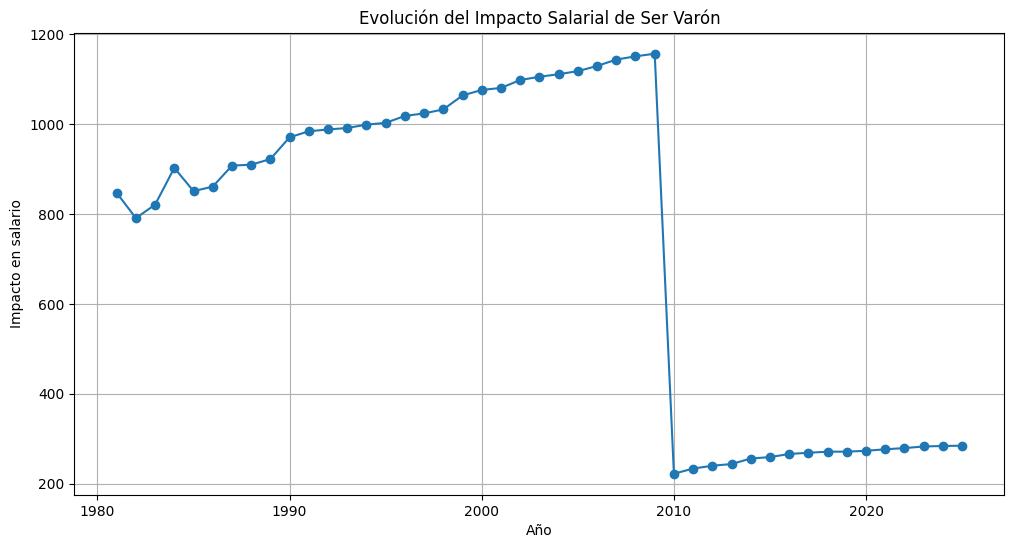

In [4]:
# =========================
# 6. GRÁFICO: IMPACTO GENERO VARÓNN
# =========================

# Detectar nombre de la columna automáticamente
import matplotlib.pyplot as plt
col_genero = [col for col in coeficientes.columns if 'genero_' in col][0]

plt.figure(figsize=(12, 6))

plt.plot(coeficientes['anio'], coeficientes[col_genero], marker='o')

plt.title('Evolución del Impacto Salarial de Ser Varón')
plt.xlabel('Año')
plt.ylabel('Impacto en salario')
plt.grid(True)

# Guardar gráfico
plt.savefig(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\impacto_genero_varon.png")

plt.show()

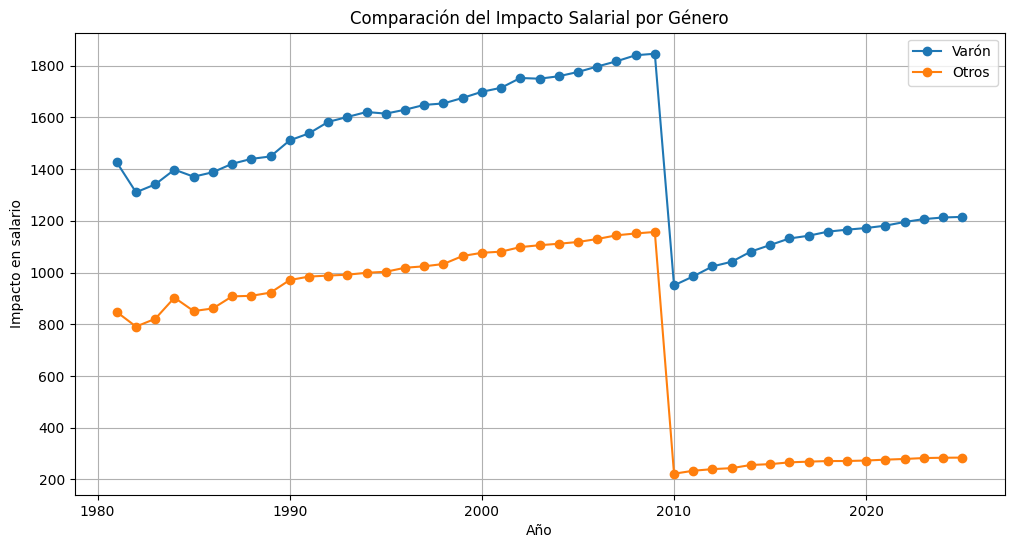

In [4]:
# =========================
# 8. GRÁFICO COMPARATIVO
# =========================

# Detectar columnas
col_varon = [col for col in coeficientes.columns if 'genero_' in col and 'varon' in col.lower()]
col_otros = [col for col in coeficientes.columns if 'genero_' in col and 'otro' in col.lower()]

plt.figure(figsize=(12, 6))

# Graficar varón
if len(col_varon) > 0:
    col_varon = col_varon[0]
    plt.plot(coeficientes['anio'], coeficientes[col_varon], marker='o', label='Varón')

# Graficar otros
if len(col_otros) > 0:
    col_otros = col_otros[0]
    plt.plot(coeficientes['anio'], coeficientes[col_otros], marker='o', label='Otros')

plt.title('Comparación del Impacto Salarial por Género')
plt.xlabel('Año')
plt.ylabel('Impacto en salario')
plt.legend()
plt.grid(True)

# Guardar
plt.savefig(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\comparacion_genero.png")

plt.show()

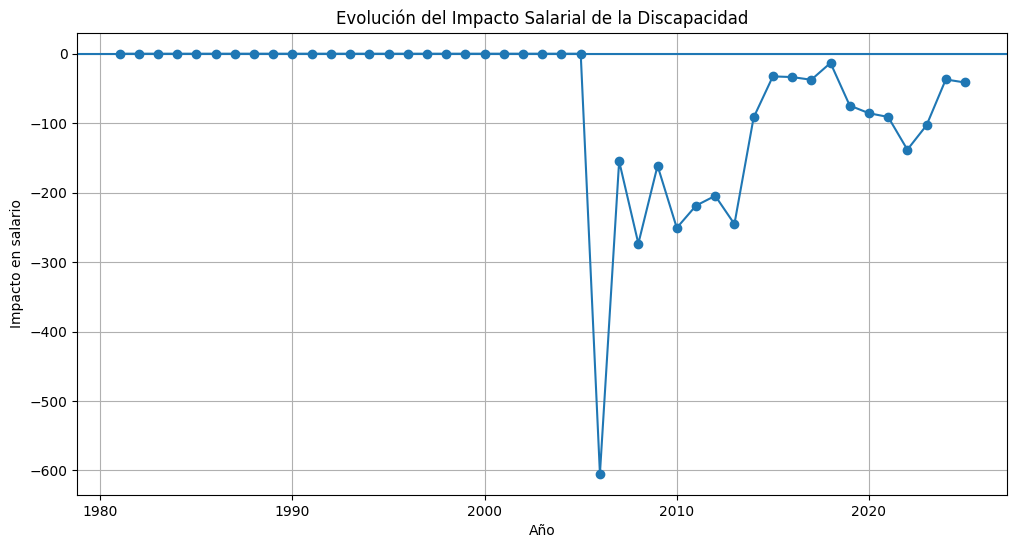

In [5]:
# =========================
# 9. GRÁFICO: IMPACTO DISCAPACIDAD
# =========================

# Buscar columna de discapacidad
col_disc = [col for col in coeficientes.columns if 'discapacidad' in col.lower()]

if len(col_disc) == 0:
    print("⚠️ No se encontró la variable 'discapacidad'")
else:
    col_disc = col_disc[0]

    plt.figure(figsize=(12, 6))
    plt.plot(coeficientes['anio'], coeficientes[col_disc], marker='o')

    plt.title('Evolución del Impacto Salarial de la Discapacidad')
    plt.xlabel('Año')
    plt.ylabel('Impacto en salario')
    plt.grid(True)

    # Línea de referencia en 0
    plt.axhline(0)

    # Guardar
    plt.savefig(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\impacto_discapacidad.png")

    plt.show()

In [5]:
coeficientes.head()

,anio,edad,discapacidad,tono_piel,genero_otros,genero_varon,seniority_LEAD,seniority_MID,seniority_SR
0,1981,-5.765064,-9.094947e-13,-15.884009,847.291898,1425.801594,13676.834520,1825.351967,6894.256893
1,1982,-5.768737,-6.821210e-13,-15.629499,791.124824,1310.328779,13641.560825,1860.344735,6820.612066
2,1983,-4.120299,-3.655032e-11,1.530620,821.098166,1340.895362,13733.520871,1902.187008,6801.759658
3,1984,-2.803402,6.252776e-13,13.098802,902.886768,1397.856825,13616.303427,1917.221360,6744.780417
4,1985,-1.424119,7.389644e-13,-8.168179,851.098304,1370.644794,13685.633596,1968.649871,6820.076153


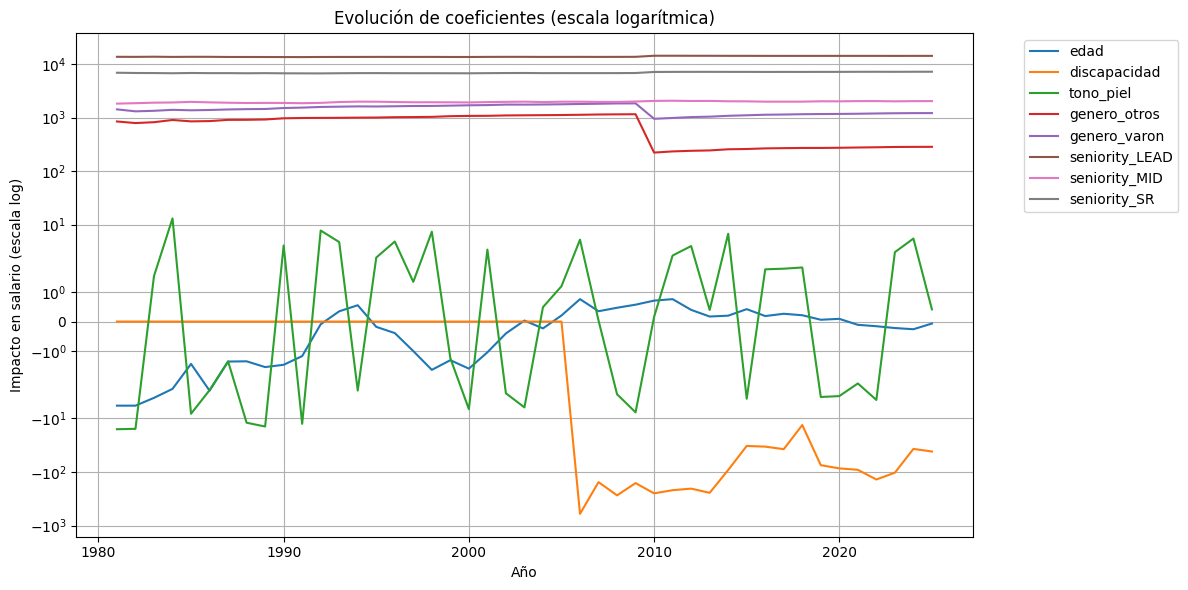

In [7]:
import matplotlib.pyplot as plt

cols = [col for col in coeficientes.columns if col != 'anio']

plt.figure(figsize=(12, 6))

for col in cols:
    plt.plot(coeficientes['anio'], coeficientes[col], label=col)

plt.yscale('symlog')  # 🔥 clave: escala log simétrica (acepta negativos)

plt.title('Evolución de coeficientes (escala logarítmica)')
plt.xlabel('Año')
plt.ylabel('Impacto en salario (escala log)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# =========================
# 1. CARGA
# =========================

empleados = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\empleados.csv")
puestos = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\puestos.csv")
salarios = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\salarios.csv")

salarios = salarios.rename(columns={'sueldo': 'salario'})
salarios['mes'] = pd.to_datetime(salarios['mes'], errors='coerce')
salarios['anio'] = salarios['mes'].dt.year

# =========================
# 2. PREPARACIÓN GLOBAL
# =========================

df_all = salarios.sort_values('mes').drop_duplicates(['anio', 'id_empleado'], keep='last')
df_all = empleados.merge(df_all, on='id_empleado')
df_all = df_all.merge(puestos, on='id_puesto')

# Dummies globales
df_all = pd.get_dummies(
    df_all,
    columns=['genero', 'etnia'],
    drop_first=True
)

# Centrar edad global
df_all['edad'] = df_all['edad'] - df_all['edad'].mean()

# Variables candidatas
columnas_base = [
    col for col in df_all.columns
    if any(x in col for x in ['genero_', 'etnia_', 'edad', 'discapacidad'])
]

# =========================
# 3. DETECTAR AÑO DE APARICIÓN
# =========================

anio_inicio_variable = {}

for col in columnas_base:
    for anio, df_anio in df_all.groupby('anio'):
        if df_anio[col].nunique() > 1:  # 🔥 hay variación real
            anio_inicio_variable[col] = anio
            break

# =========================
# 4. REGRESIÓN DINÁMICA
# =========================

resultados = []

for anio, df_anio in df_all.groupby('anio'):

    # Variables disponibles en ese año
    columnas_validas = [
        col for col in columnas_base
        if anio_inicio_variable.get(col, 9999) <= anio
    ]

    # Filtrar variables sin variación ese año (doble check)
    columnas_validas = [
        col for col in columnas_validas
        if df_anio[col].nunique() > 1
    ]

    if len(columnas_validas) == 0 or len(df_anio) < 10:
        continue

    X = df_anio[columnas_validas]
    y = df_anio['salario']

    model = LinearRegression().fit(X, y)

    coef_dict = {'anio': anio}

    for feature, coef in zip(X.columns, model.coef_):
        coef_dict[feature] = coef

    resultados.append(coef_dict)

# =========================
# 5. RESULTADO FINAL
# =========================

coeficientes = pd.DataFrame(resultados).sort_values('anio')

# Opcional: completar con NaN (mejor que 0)
coeficientes = coeficientes.sort_index(axis=1)

print(coeficientes.head())

   anio  discapacidad       edad  etnia_asiatico  etnia_blanco  etnia_griego  \
0  1981           NaN   3.580565     -104.439908   1123.795636   2514.910117   
1  1982           NaN -18.163617     -380.330262    399.618695    336.821978   
2  1983           NaN  -2.911760     -337.362603   -627.985963   -112.188767   
3  1984           NaN  -8.176176     -866.547426  -1283.389655   -691.326083   
4  1985           NaN  -3.495185     -204.160998   -814.041051   -269.708494   

   etnia_indio  etnia_latino  genero_otros  genero_varon  
0  1032.683360   -774.603616   1878.604879   1209.625438  
1  -335.574003   -639.559370   2051.097334   2057.793966  
2  -446.820189  -1344.757897   1839.186140   2279.396654  
3 -1037.653558  -1235.517528   1995.616521   2287.842505  
4  -497.507936   -692.418822   1572.549423   2221.188794  


In [12]:
print(coeficientes.head())

   anio  discapacidad       edad  etnia_asiatico  etnia_blanco  etnia_griego  \
0  1981           NaN   3.580565     -104.439908   1123.795636   2514.910117   
1  1982           NaN -18.163617     -380.330262    399.618695    336.821978   
2  1983           NaN  -2.911760     -337.362603   -627.985963   -112.188767   
3  1984           NaN  -8.176176     -866.547426  -1283.389655   -691.326083   
4  1985           NaN  -3.495185     -204.160998   -814.041051   -269.708494   

   etnia_indio  etnia_latino  genero_otros  genero_varon  
0  1032.683360   -774.603616   1878.604879   1209.625438  
1  -335.574003   -639.559370   2051.097334   2057.793966  
2  -446.820189  -1344.757897   1839.186140   2279.396654  
3 -1037.653558  -1235.517528   1995.616521   2287.842505  
4  -497.507936   -692.418822   1572.549423   2221.188794  


In [13]:
# Valores únicos
roles = puestos['rol'].dropna().unique().tolist()
departamentos = puestos['departamento'].dropna().unique().tolist()
seniority = puestos['seniority'].dropna().unique().tolist()

print("ROLES:")
print(sorted(roles))

print("\nDEPARTAMENTOS:")
print(sorted(departamentos))

print("\nSENIORITY:")
print(sorted(seniority))

ROLES:
['Analista', 'Analista MKT', 'Arquitecto', 'BizDev', 'Contador', 'Content', 'Controller', 'Data', 'Dev', 'Ejecutivo', 'Finanzas Manager', 'Gerente', 'HR Analyst', 'HR Manager', 'HRBP', 'Manager MKT', 'Marketing', 'Recruiter', 'Representante', 'SEO', 'Soporte', 'Sysadmin', 'Tesorería', 'Training']

DEPARTAMENTOS:
['Finanzas', 'IT', 'Marketing', 'RRHH', 'Ventas']

SENIORITY:
['JR', 'LEAD', 'MID', 'SR']


In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# =========================
# 1. CARGA
# =========================

empleados = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\empleados.csv")
puestos = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\puestos.csv")
salarios = pd.read_csv(r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\salarios.csv")

salarios = salarios.rename(columns={'sueldo': 'salario'})
salarios['mes'] = pd.to_datetime(salarios['mes'], errors='coerce')
salarios['anio'] = salarios['mes'].dt.year

# =========================
# 2. CATEGORÍAS FIJAS
# =========================

generos = ['mujer', 'varon', 'otros']
etnias = ['blanco', 'griego', 'indio', 'latino', 'asiatico', 'afrodescendiente']
roles = ['Analista', 'Analista MKT', 'Arquitecto', 'BizDev', 'Contador', 'Content',
         'Controller', 'Data', 'Dev', 'Ejecutivo', 'Finanzas Manager', 'Gerente',
         'HR Analyst', 'HR Manager', 'HRBP', 'Manager MKT', 'Marketing',
         'Recruiter', 'Representante', 'SEO', 'Soporte', 'Sysadmin',
         'Tesorería', 'Training']
departamentos = ['Finanzas', 'IT', 'Marketing', 'RRHH', 'Ventas']
senioritys = ['JR', 'LEAD', 'MID', 'SR']

# =========================
# 3. RESULTADOS
# =========================

resultados = []

# =========================
# 4. LOOP POR AÑO
# =========================

for anio, df_anio_salarios in salarios.groupby('anio'):

    df_actual = df_anio_salarios.sort_values('mes').drop_duplicates('id_empleado', keep='last')

    df_master = empleados.merge(df_actual, on='id_empleado')
    df_master = df_master.merge(puestos, on='id_puesto')

    # =========================
    # 4.1 FIJAR CATEGORÍAS
    # =========================

    df_master['genero'] = pd.Categorical(df_master['genero'], categories=generos)
    df_master['etnia'] = pd.Categorical(df_master['etnia'], categories=etnias)
    df_master['rol'] = pd.Categorical(df_master['rol'], categories=roles)
    df_master['departamento'] = pd.Categorical(df_master['departamento'], categories=departamentos)
    df_master['seniority'] = pd.Categorical(df_master['seniority'], categories=senioritys)

    # =========================
    # 4.2 DUMMIES
    # =========================

    df_dummies = pd.get_dummies(
        df_master,
        columns=['genero', 'etnia', 'rol', 'departamento', 'seniority'],
        drop_first=True
    )

    # =========================
    # 4.3 VARIABLES X
    # =========================

    columnas_x = [
        col for col in df_dummies.columns
        if any(x in col for x in [
            'genero_', 'etnia_', 'rol_', 'departamento_', 'seniority_',
            'edad', 'discapacidad'
        ])
    ]

    # Filtrar columnas sin variación
    columnas_x = [col for col in columnas_x if df_dummies[col].nunique() > 1]

    if len(columnas_x) == 0 or len(df_dummies) < 10:
        continue

    # =========================
    # 4.4 MATRICES
    # =========================

    X = df_dummies[columnas_x].copy()
    y = df_dummies['salario']

    # Centrar edad por año
    if 'edad' in X.columns:
        X['edad'] = X['edad'] - X['edad'].mean()

    # =========================
    # 4.5 MODELO
    # =========================

    model = LinearRegression().fit(X, y)

    coef_dict = {
        'anio': anio,
        'intercepto': model.intercept_
    }

    for feature, coef in zip(X.columns, model.coef_):
        coef_dict[feature] = coef

    resultados.append(coef_dict)

# =========================
# 5. RESULTADO FINAL
# =========================

coeficientes = pd.DataFrame(resultados).sort_values('anio')
coeficientes = coeficientes.reindex(sorted(coeficientes.columns), axis=1)

# =========================
# 6. EXPORTAR
# =========================

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\coeficientes_regresion_anual.csv"
coeficientes.to_csv(output_path, index=False)

print("✅ Proceso completado")
print(coeficientes.head())

✅ Proceso completado
   anio  departamento_IT  departamento_Marketing  departamento_RRHH  \
0  1981      -993.983154             -807.450956        -956.465381   
1  1982      -986.851403             -985.910373       -1022.689965   
2  1983     -1011.323055             -981.115328        -972.558878   
3  1984     -1177.943877            -1179.526506       -1106.877219   
4  1985     -1198.896828            -1186.394861       -1119.022159   

   departamento_Ventas  discapacidad      edad  etnia_afrodescendiente  \
0         -1378.504956           NaN -0.131242               12.152554   
1         -1200.487195           NaN -1.357003             -107.864602   
2         -1103.160299           NaN -1.321826             -134.157270   
3         -1316.869166           NaN -1.294857              -67.300107   
4         -1355.411255           NaN -0.709009              -86.505178   

   etnia_asiatico  etnia_griego  ...  rol_Recruiter  rol_Representante  \
0      384.953040    231.251528  

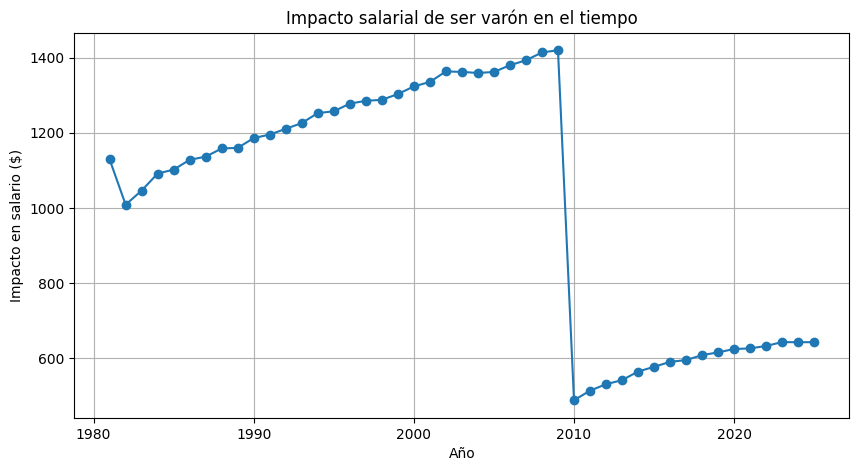

In [16]:
import matplotlib.pyplot as plt

# Detectar columna de varón
col_varon = [col for col in coeficientes.columns if 'genero_varon' in col][0]

plt.figure(figsize=(10, 5))

plt.plot(coeficientes['anio'], coeficientes[col_varon], marker='o')

plt.title('Impacto salarial de ser varón en el tiempo')
plt.xlabel('Año')
plt.ylabel('Impacto en salario ($)')
plt.grid(True)

plt.show()

In [17]:
print(coeficientes.columns.tolist())

['anio', 'departamento_IT', 'departamento_Marketing', 'departamento_RRHH', 'departamento_Ventas', 'discapacidad', 'edad', 'etnia_afrodescendiente', 'etnia_asiatico', 'etnia_griego', 'etnia_indio', 'etnia_latino', 'genero_otros', 'genero_varon', 'intercepto', 'rol_Analista MKT', 'rol_Arquitecto', 'rol_BizDev', 'rol_Contador', 'rol_Content', 'rol_Controller', 'rol_Data', 'rol_Dev', 'rol_Ejecutivo', 'rol_Finanzas Manager', 'rol_Gerente', 'rol_HR Analyst', 'rol_HR Manager', 'rol_HRBP', 'rol_Manager MKT', 'rol_Marketing', 'rol_Recruiter', 'rol_Representante', 'rol_SEO', 'rol_Soporte', 'rol_Sysadmin', 'rol_Tesorería', 'rol_Training', 'seniority_LEAD', 'seniority_MID', 'seniority_SR']


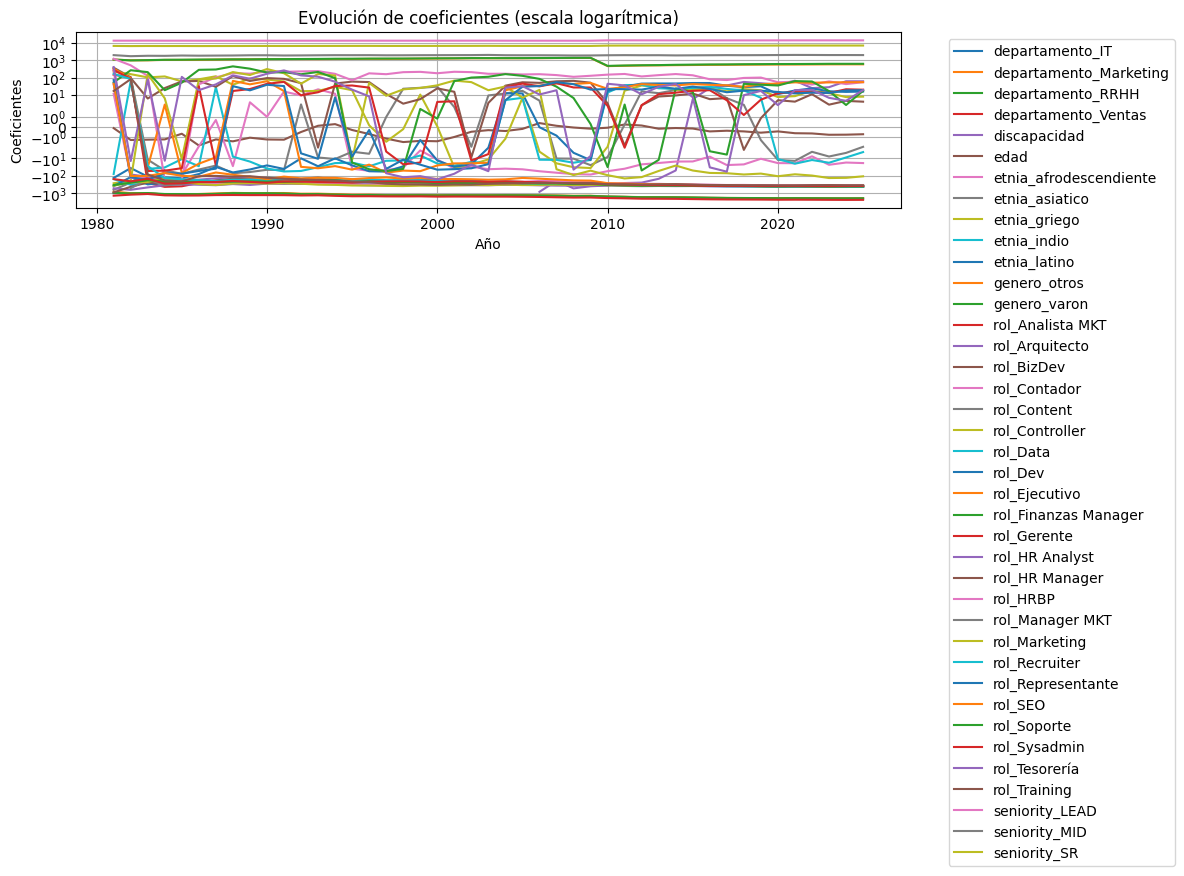

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# columnas a graficar (excluyendo anio)
cols = [c for c in coeficientes.columns if c not in ['anio', 'intercepto']]

for col in cols:
    plt.plot(coeficientes['anio'], coeficientes[col], label=col)

plt.yscale('symlog')  # 🔥 clave

plt.title('Evolución de coeficientes (escala logarítmica)')
plt.xlabel('Año')
plt.ylabel('Coeficientes')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

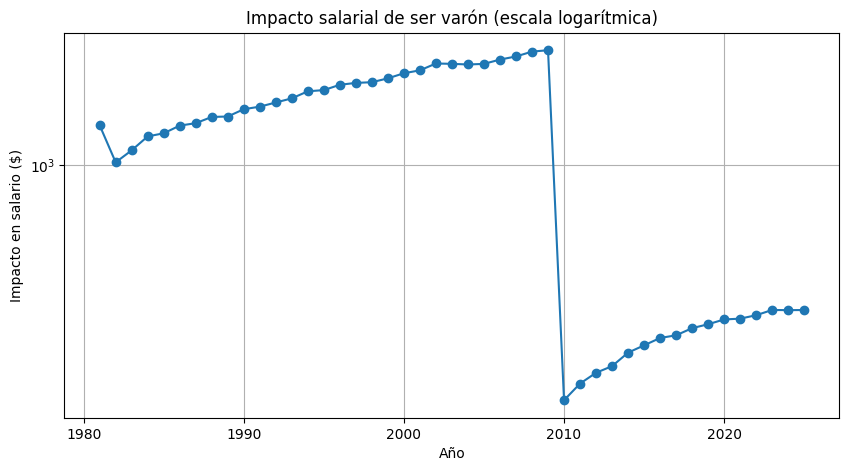

In [19]:
import matplotlib.pyplot as plt

# detectar columna
col_varon = [col for col in coeficientes.columns if 'genero_varon' in col][0]

plt.figure(figsize=(10, 5))

plt.plot(coeficientes['anio'], coeficientes[col_varon], marker='o')

# 🔥 clave: escala log simétrica
plt.yscale('symlog')

plt.title('Impacto salarial de ser varón (escala logarítmica)')
plt.xlabel('Año')
plt.ylabel('Impacto en salario ($)')

plt.grid(True)
plt.show()

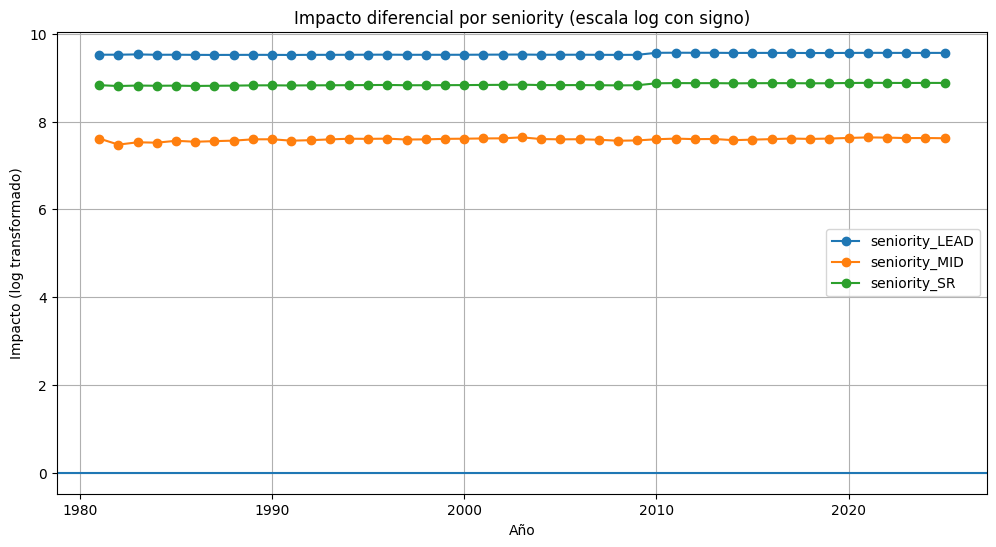

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# columnas de seniority
cols_seniority = [c for c in coeficientes.columns if 'seniority_' in c]

# función log con signo
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

plt.figure(figsize=(12, 6))

for col in cols_seniority:
    y = signed_log(coeficientes[col])
    plt.plot(coeficientes['anio'], y, marker='o', label=col)

plt.axhline(0)

plt.title('Impacto diferencial por seniority (escala log con signo)')
plt.xlabel('Año')
plt.ylabel('Impacto (log transformado)')

plt.legend()
plt.grid(True)

plt.show()

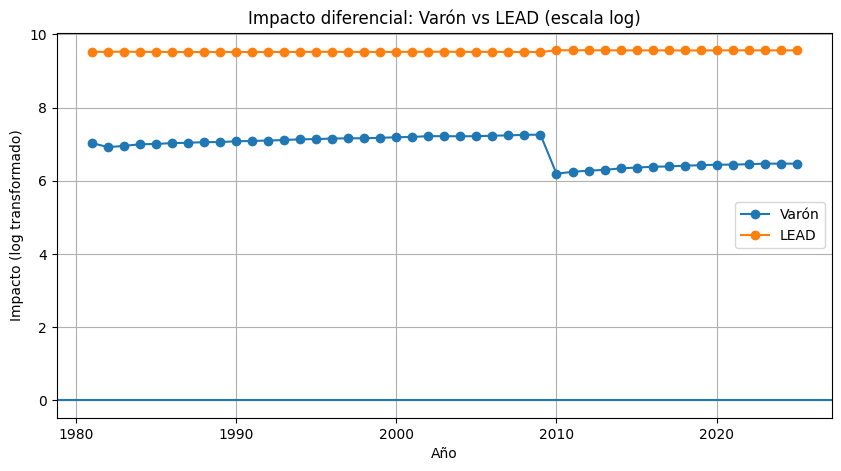

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# columnas
col_varon = [c for c in coeficientes.columns if 'genero_varon' in c][0]
col_lead = [c for c in coeficientes.columns if 'seniority_LEAD' in c][0]

# transformación log con signo
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

plt.figure(figsize=(10, 5))

plt.plot(coeficientes['anio'], signed_log(coeficientes[col_varon]),
         marker='o', label='Varón')

plt.plot(coeficientes['anio'], signed_log(coeficientes[col_lead]),
         marker='o', label='LEAD')

plt.axhline(0)

plt.title('Impacto diferencial: Varón vs LEAD (escala log)')
plt.xlabel('Año')
plt.ylabel('Impacto (log transformado)')

plt.legend()
plt.grid(True)

plt.show()

In [23]:
import numpy as np
import pandas as pd

# =========================
# 1. FUNCIÓN LOG CON SIGNO
# =========================

def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

# =========================
# 2. COPIA DEL DATASET
# =========================

coeficientes_log = coeficientes.copy()

# =========================
# 3. APLICAR TRANSFORMACIÓN
# =========================

cols_transformar = [col for col in coeficientes_log.columns if col != 'anio']

coeficientes_log[cols_transformar] = coeficientes_log[cols_transformar].apply(signed_log)

# =========================
# 4. LIMPIEZA (IMPORTANTE PARA POWER BI)
# =========================

# Reemplazar infinitos o valores raros (por seguridad)
coeficientes_log.replace([np.inf, -np.inf], np.nan, inplace=True)

# (opcional) rellenar NaN con 0
coeficientes_log.fillna(0, inplace=True)

# =========================
# 5. EXPORTAR
# =========================

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\tabla_coeficientes_log.csv"

coeficientes_log.to_csv(output_path, index=False)

print("✅ Dataset transformado y exportado correctamente")
print(coeficientes_log.head())

✅ Dataset transformado y exportado correctamente
   anio  departamento_IT  departamento_Marketing  departamento_RRHH  \
0  1981        -6.902726               -6.695120          -6.864290   
1  1982        -6.895532               -6.894579          -6.931169   
2  1983        -6.920003               -6.889709          -6.880958   
3  1984        -7.072374               -7.073716          -7.010201   
4  1985        -7.089991               -7.079517          -7.021104   

   departamento_Ventas  discapacidad      edad  etnia_afrodescendiente  \
0            -7.229480           0.0 -0.123316                2.576616   
1            -7.091315           0.0 -0.857391               -4.690105   
2            -7.006840           0.0 -0.842354               -4.906439   
3            -7.183771           0.0 -0.830671               -4.223911   
4            -7.212598           0.0 -0.535914               -4.471698   

   etnia_asiatico  etnia_griego  ...  rol_Recruiter  rol_Representante  \
0    

In [24]:
import numpy as np

coeficientes_log = coeficientes.copy()

# función log con signo
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

# columnas a transformar
cols = [c for c in coeficientes_log.columns if c != 'anio']

# aplicar transformación
coeficientes_log[cols] = coeficientes_log[cols].apply(signed_log)

# =========================
# 🔥 CLAVE: eliminar falsos ceros
# =========================

coeficientes_log[cols] = coeficientes_log[cols].replace(0, np.nan)

# =========================
# EXPORTAR
# =========================

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\tabla_coeficientes_log.csv"

coeficientes_log.to_csv(output_path, index=False)

print("✅ Exportado sin ceros problemáticos")

✅ Exportado sin ceros problemáticos


In [25]:
coeficientes_log.head()

,anio,departamento_IT,departamento_Marketing,departamento_RRHH,departamento_Ventas,discapacidad,edad,etnia_afrodescendiente,etnia_asiatico,etnia_griego,...,rol_Recruiter,rol_Representante,rol_SEO,rol_Soporte,rol_Sysadmin,rol_Tesorería,rol_Training,seniority_LEAD,seniority_MID,seniority_SR
0,1981,-6.902726,-6.695120,-6.864290,-7.229480,NaN,-0.123316,2.576616,5.955716,5.447821,...,5.150797,4.334254,3.840459,-5.827588,-5.043082,6.036500,2.925710,9.522802,7.613475,8.829198
1,1982,-6.895532,-6.894579,-6.931169,-7.091315,NaN,-0.857391,-4.690105,4.711603,5.103023,...,4.463293,-4.810410,-4.645545,-5.516890,-5.338483,-2.720911,4.446928,9.522943,7.474461,8.808977
2,1983,-6.920003,-6.889709,-6.880958,-7.006840,NaN,-0.842354,-4.906439,-2.553624,4.680793,...,-3.354397,-5.134157,-4.624930,-5.195860,-4.997527,4.381774,-4.439111,9.529669,7.527533,8.820350
3,1984,-7.072374,-7.073716,-7.010201,-7.183771,NaN,-0.830671,-4.223911,-3.905988,4.804015,...,-4.912247,-4.241061,-4.243452,-5.350166,-5.643385,-2.684211,-5.219190,9.521072,7.518678,8.814995
4,1985,-7.089991,-7.079517,-7.021104,-7.212598,NaN,-0.535914,-4.471698,-4.346254,4.161984,...,-5.068249,-4.342070,-4.611119,-5.430922,-5.587480,4.747152,-5.344033,9.522543,7.561712,8.818574


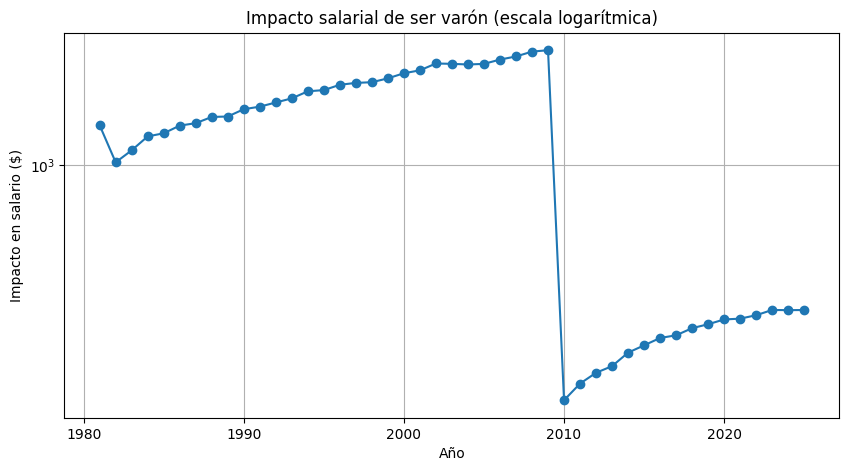

In [26]:
import matplotlib.pyplot as plt

# detectar columna
col_varon = [col for col in coeficientes.columns if 'genero_varon' in col][0]

plt.figure(figsize=(10, 5))

plt.plot(coeficientes['anio'], coeficientes[col_varon], marker='o')

# 🔥 clave: escala log simétrica
plt.yscale('symlog')

plt.title('Impacto salarial de ser varón (escala logarítmica)')
plt.xlabel('Año')
plt.ylabel('Impacto en salario ($)')

plt.grid(True)
plt.show()